<a href="https://colab.research.google.com/github/Chaotic-Legend/CMP-415-Codes/blob/main/Homework%20%235%3A%20Decision%20Tree%20and%20Random%20Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework #5: Random Forest Model for Churn Analysis
#### CMP 415: Machine Learning - Isaac D. Hoyos

In this assignment, you will build a robust classification pipeline to predict customer churn. Please download the `Churn_Modelling.csv` dataset (available on [Kaggle](https://www.kaggle.com/datasets/shrutimechlearn/churn-modelling)). It contains features such as credit score, geography, gender, age, and tenure for bank customers, with a binary target Exited.

In [1]:
import os
import pandas as pd
from google.colab import files
from IPython.display import display

csv_filename = "Churn_Modelling.csv"

# Check whether the CSV file already exists.
if not os.path.exists(csv_filename):
    print(f"⬆️ Please upload the \"{csv_filename}\" file...\n")

    while True:
        uploaded = files.upload()

        # Get the uploaded CSV file name.
        uploaded_filename = list(uploaded.keys())[0]

        # Validate the correct CSV file.
        if uploaded_filename == csv_filename:
            print(f"\n✅ File \"{csv_filename}\" has been uploaded successfully!")
            break
        else:
            print(f"\n❌ Error: Please upload the correct \"{csv_filename}\" file...\n")
else:
    print(f"✅ Using the existing \"{csv_filename}\" file.")

# Load the first five rows of the dataset.
df = pd.read_csv(csv_filename)
print("\n=== First 5 Rows of the Churn_Modelling.csv DataFrame ===")
display(df.head())

⬆️ Please upload the "Churn_Modelling.csv" file...



Saving Churn_Modelling.csv to Churn_Modelling.csv

✅ File "Churn_Modelling.csv" has been uploaded successfully!

=== First 5 Rows of the Churn_Modelling.csv DataFrame ===


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


1. Feature Selection: Drop the `RowNumber`, `CustomerId`, and `Surname` columns.

In [2]:
# Remove unnecessary columns and display the dataset.
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1, errors='ignore')
print("=== First 5 Rows of the DataFrame After Dropping ===")
display(df.head())

=== First 5 Rows of the DataFrame After Dropping ===


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


2. Categorical Encoding: Use `pd.get_dummies()` with `drop_first=True` to transform the `Geography` column.

In [3]:
# Convert the 'Geography' column into one-hot encoded variables.
df = pd.get_dummies(df, columns=["Geography"], drop_first=True)

# Convert the 'Gender' column into a binary numerical format.
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})

# Display the first five rows of the updated dataset.
print("=== First 5 Rows of the DataFrame After Encoding ===")

display(df.head())

=== First 5 Rows of the DataFrame After Encoding ===


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


3. Split the dataset into a training set (75%) and a test set (25%).

In [4]:
# Split the dataset into a training set (75%) and a test set (25%).
from sklearn.model_selection import train_test_split

X = df.drop("Exited", axis=1)
y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

4. Baseline Model: Build a decision tree model with `max-depth=2`. Show the prediction accuracy and visualize the decision tree.

Decision Tree Accuracy: 0.8464


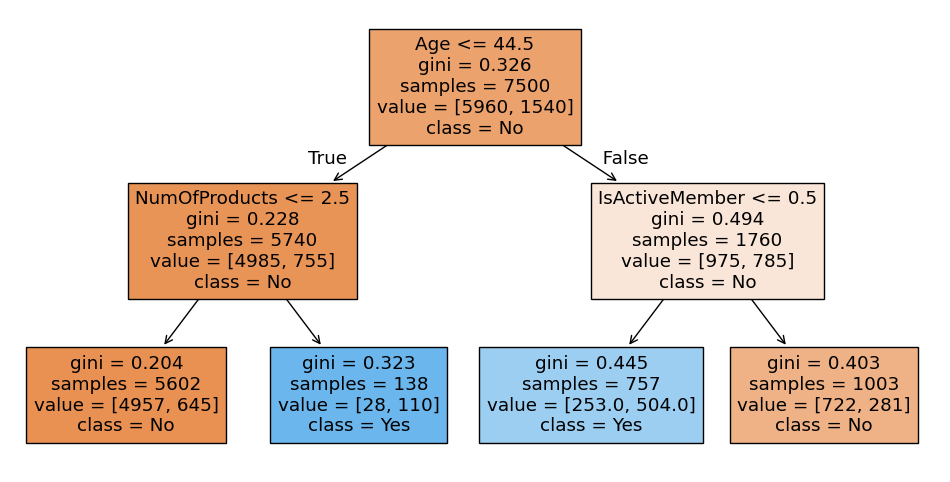

In [5]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

# Initialize and train a decision tree classifier with a limited depth.
dt = DecisionTreeClassifier(max_depth=2, random_state=42)
dt.fit(X_train, y_train)

# Generate predictions on the test dataset.
y_pred = dt.predict(X_test)

# Evaluate model performance using accuracy metric.
accuracy = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy:", accuracy)

# Visualize the trained decision tree structure.
plt.figure(figsize=(12, 6))
plot_tree(dt, feature_names=X.columns, class_names=["No", "Yes"], filled=True)
plt.show()

5. Construct a `RandomForestClassifier` and use `GridSearchCV` to find the optimal configuration. The grid search should go over the following options:

    - max_depth: [2, 5, None]
    - min_samples_leaf: [1, 2, 5]
    - n_estimators: [50, 100, 200]

Perform a 5-fold cross-validation in the grid search to select the best values for these hyperparameters.

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Initialize a random forest classifier with a fixed seed for reproducibility.
rf = RandomForestClassifier(random_state=42)

# Define the hyperparameter search space for tuning the model.
param_grid = {
    "max_depth": [2, 5, None],
    "min_samples_leaf": [1, 2, 5],
    "n_estimators": [50, 100, 200]}

# Set up grid search with 5-fold cross-validation.
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1)

# Run grid search on training data to test all parameter combinations.
grid_search.fit(X_train, y_train)

# Extract the best-performing model from the grid search results.
best_rf = grid_search.best_estimator_

# Display the optimal hyperparameters found during tuning.
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 100}


6. (Optional for undergraduates) Training large ensembles can be time-consuming. Save your best-fit model to a file named `rf_model.pickle`, and demonstrate that you can retreive the model from the pickle file.

In [7]:
import pickle

# Save the trained Random Forest model to a file for later use.
with open("rf_model.pickle", "wb") as file:
    pickle.dump(best_rf, file)

print("The model has been successfully saved to 'rf_model.pickle'.")

# Load the saved model from the file to verify it can be restored correctly.
with open("rf_model.pickle", "rb") as file:
    loaded_model = pickle.load(file)

print("\nThe model has been successfully loaded from 'rf_model.pickle'.\n")
print(loaded_model)

The model has been successfully saved to 'rf_model.pickle'.

The model has been successfully loaded from 'rf_model.pickle'.

RandomForestClassifier(min_samples_leaf=5, random_state=42)


7. Performance Metrics. Show the accuracy, precision, and recall of the best-fit model on the test set.

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Generate predictions on the test set using the loaded model.
y_pred = loaded_model.predict(X_test)

# Calculate evaluation metrics to assess model performance.
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Display the computed performance metrics.
print("Accuracy:", accuracy)
print("\nPrecision:", precision)
print("\nRecall:", recall)

Accuracy: 0.8664

Precision: 0.7725752508361204

Recall: 0.4647887323943662


8. Analyze your model's performance: What are its strengths and weaknesses? Use metrics and error analysis to justify your conclusions.

The model achieves an accuracy of 0.8664, which indicates that it correctly classifies a large majority of customers. However, accuracy alone can be misleading in churn prediction, especially when the dataset is imbalanced. The precision score of 0.7726 suggests that when the model predicts a customer will churn, it is correct about 77 percent of the time, indicating fairly reliable positive predictions. In contrast, the recall score of 0.4648 is much lower, meaning the model identifies only about 46 percent of actual churn cases. This indicates that a large portion of customers who are likely to churn are not being identified by the model. Although the model demonstrates strong overall accuracy and maintains good precision, its relatively low recall reveals an important weakness in detecting at-risk customers. Enhancing recall through additional tuning or by addressing class imbalance would improve the model's ability to detect potential churn more reliably.